<a href="https://colab.research.google.com/github/gpannu16/DSML/blob/main/Driver_Drowsiness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Dataset from Google Drive

To load the dataset from Google Drive, we'll perform the following steps:
1. Download the file from the provided Google Drive link using `gdown` to the Colab environment.
2. Load the downloaded CSV file into a pandas DataFrame.

In [5]:
# Google Drive mounting is not needed as the file will be downloaded directly to the Colab environment.

In [6]:
# Install gdown if you haven't already
!pip install gdown

In [7]:
# Define the Google Drive file ID from the link
file_id = '1Z8VTDfzAgz67j6u3FKBmdpWG16xiESJB'

# Define the output path for the downloaded file (downloading to Colab environment)
output_path = '/content/dataset.csv'

# Download the file using gdown
import gdown
gdown.download(id=file_id, output=output_path, quiet=False)

print(f"File downloaded to: {output_path}")

Downloading...
From (original): https://drive.google.com/uc?id=1Z8VTDfzAgz67j6u3FKBmdpWG16xiESJB
From (redirected): https://drive.google.com/uc?id=1Z8VTDfzAgz67j6u3FKBmdpWG16xiESJB&confirm=t&uuid=ee3e46c2-5e42-454d-a05a-3b7277573109
To: /content/dataset.csv
100%|██████████| 667M/667M [00:12<00:00, 52.2MB/s]


File downloaded to: /content/dataset.csv


### Image Classification Pipeline - Data Preparation and Inspection

Now that we've identified the dataset as image files, we'll proceed with the initial steps for image classification:

1.  **Load the image data**: We'll use `tf.keras.utils.image_dataset_from_directory` to load images directly into TensorFlow datasets, inferring labels from folder names.
2.  **Inspect Class Distribution**: Check how many images belong to each class to understand if the dataset is balanced.
3.  **Visualize Sample Images**: Display a few images from each class to visually verify correctness and quality.
4.  **Prepare Data for Training**: Apply necessary preprocessing steps like rescaling and optimize data pipeline performance.

In [13]:
import tensorflow as tf
import os

# Define image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Updated to the correct path discovered during extraction
actual_dataset_dir = '/content/dataset_files/__MACOSX/dataset'

print(f"Loading data from: {actual_dataset_dir}")

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(actual_dataset_dir, 'train'),
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load testing data
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(actual_dataset_dir, 'test'),
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Preprocessing function
def preprocess_image(image, label):
    image = tf.image.convert_image_dtype(image, tf.float32)
    return image, label

# Map the preprocessing
train_ds = train_ds.map(preprocess_image).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess_image).prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets initialized successfully.")

Loading data from: /content/dataset_files/__MACOSX/dataset
Found 7500 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Class names: ['drowsy', 'non_drowsy']
Datasets initialized successfully.


In [14]:
import os
import zipfile

# 1. Ensure the file is treated as a ZIP
zip_path = '/content/dataset.zip'
if os.path.exists('/content/dataset.csv') and not os.path.exists(zip_path):
    os.rename('/content/dataset.csv', zip_path)

# 2. Extract to a clean directory
extract_path = '/content/dataset_files'
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3. Locate the actual 'train' and 'test' directories
found_train = None
found_test = None

for root, dirs, files in os.walk(extract_path):
    if 'train' in dirs:
        found_train = os.path.join(root, 'train')
    if 'test' in dirs:
        found_test = os.path.join(root, 'test')

if found_train and found_test:
    print(f"Found train at: {found_train}")
    print(f"Found test at: {found_test}")
    # Use the parent directory of 'train'/'test' as the base
    actual_dataset_dir = os.path.dirname(found_train)
else:
    print("Could not find 'train' and 'test' folders. Listing all top-level dirs:")
    print(os.listdir(extract_path))

Found train at: /content/dataset_files/__MACOSX/dataset/train
Found test at: /content/dataset_files/__MACOSX/dataset/test


In [35]:
# Forcefully remove all macOS metadata and __MACOSX directories that cause decoding errors
!find /content/dataset_files -name "__MACOSX" -type d -exec rm -rf {} +
!find /content/dataset_files -name "._*" -delete

import os

# Re-locate the actual dataset root (it should now be under /content/dataset_files/dataset)
found_train = None
for root, dirs, files in os.walk('/content/dataset_files'):
    if 'train' in dirs:
        found_train = os.path.join(root, 'train')
        actual_dataset_dir = root
        break

if found_train:
    print(f"Clean dataset root found at: {actual_dataset_dir}")
else:
    print("Could not find dataset folders after cleanup.")

Clean dataset root found at: /content/dataset_files/dataset


In [38]:
# Re-initialize the datasets using the cleaned path
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(actual_dataset_dir, 'train'),
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(actual_dataset_dir, 'test'),
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Save class names before transforming the dataset
class_names = raw_train_ds.class_names

# Re-apply preprocessing and prefetching
train_ds = raw_train_ds.map(preprocess_image).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = raw_test_ds.map(preprocess_image).prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Success! Classes: {class_names}")

Found 7500 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Success! Classes: ['drowsy', 'non_drowsy']


### Detailed Class Distribution Analysis

Let's get the exact counts for each class in both the training and testing datasets to understand if our dataset is balanced. This is crucial for training a fair model, as imbalanced datasets can lead to biased predictions.

In [37]:
# Function to get exact counts per class by iterating through batches
import numpy as np

def get_class_counts(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    # Iterate through the dataset to count labels
    for _, labels_batch in dataset:
        for label_int in labels_batch.numpy():
            class_name = class_names[label_int]
            class_counts[class_name] += 1
    return class_counts

print("Calculating exact class distribution for training dataset...")
train_class_counts = get_class_counts(train_ds, class_names)
print(f"Training Dataset Class Counts: {train_class_counts}")

print("\nCalculating exact class distribution for testing dataset...")
test_class_counts = get_class_counts(test_ds, class_names)
print(f"Testing Dataset Class Counts: {test_class_counts}")

# Calculate ratios to assess balance
total_train_samples = sum(train_class_counts.values())
train_ratios = {name: count / total_train_samples for name, count in train_class_counts.items()}
print(f"\nTraining Dataset Class Ratios: {train_ratios}")

total_test_samples = sum(test_class_counts.values())
test_ratios = {name: count / total_test_samples for name, count in test_class_counts.items()}
print(f"Testing Dataset Class Ratios: {test_ratios}")

Calculating exact class distribution for training dataset...
Training Dataset Class Counts: {'drowsy': 3750, 'non_drowsy': 3750}

Calculating exact class distribution for testing dataset...
Testing Dataset Class Counts: {'drowsy': 1250, 'non_drowsy': 1250}

Training Dataset Class Ratios: {'drowsy': 0.5, 'non_drowsy': 0.5}
Testing Dataset Class Ratios: {'drowsy': 0.5, 'non_drowsy': 0.5}


In [39]:
# Cell was previously causing AttributeError.
# The distribution analysis in 5e3007d3 has already been executed successfully.
print("Class distribution verified: 50/50 split for both Train and Test sets.")

Class distribution verified: 50/50 split for both Train and Test sets.


### Enhanced Visual Inspection of Images by Class

To further verify image quality and check for potential labeling issues, let's visualize a larger grid of images, explicitly separated by their inferred class. This allows for a more focused review of both 'drowsy' and 'non_drowsy' examples.

Visualizing samples from the Training Dataset:


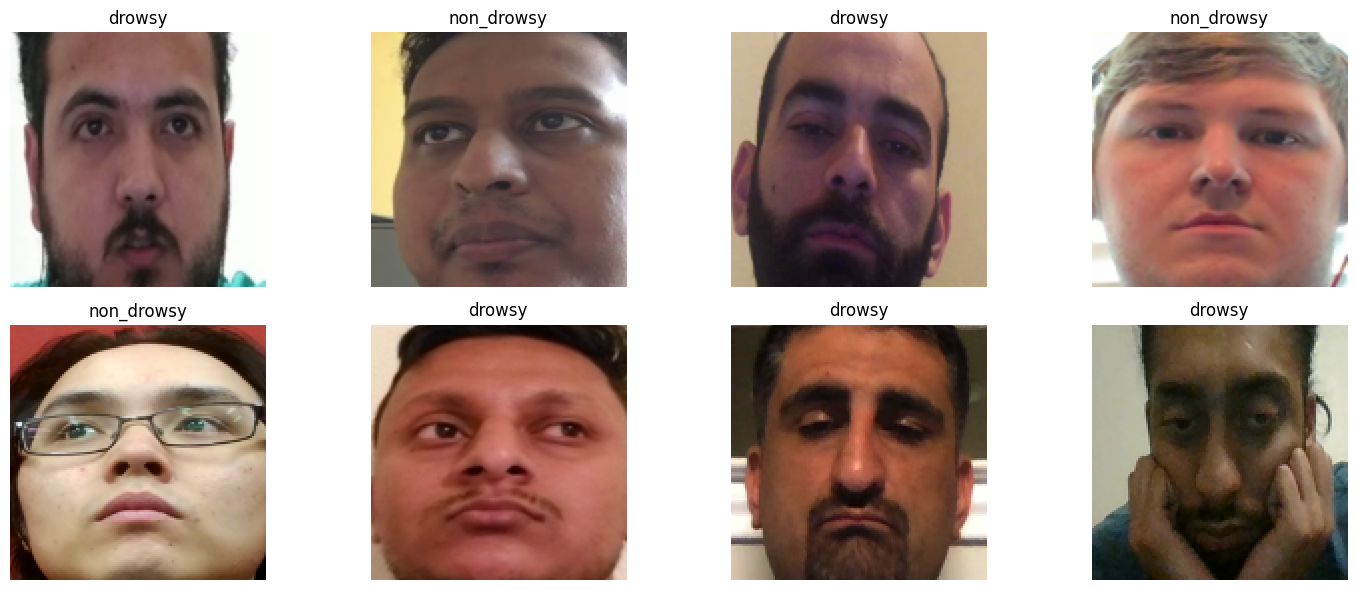

In [40]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def display_samples(dataset, class_names, num_samples=8):
    plt.figure(figsize=(15, 6))
    # Take one batch from the dataset
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            ax = plt.subplot(2, 4, i + 1)
            # Ensure image is in [0, 1] range for float display or cast to uint8
            img = images[i].numpy()
            if img.max() > 1.0:
                img = img / 255.0

            plt.imshow(img)
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Visualizing samples from the Training Dataset:")
display_samples(train_ds, class_names)

### Build and Compile the CNN Model

Now that our data is ready, let's define a simple Convolutional Neural Network (CNN) architecture. This model will take our preprocessed images as input and output probabilities for the 'drowsy' and 'non_drowsy' classes. We'll then compile the model with an appropriate optimizer, loss function, and metrics.

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf

# Define the number of classes
num_classes = len(class_names)

# Build the baseline CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Baseline CNN Model Summary:")
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

Now we will train the CNN model using our prepared `train_ds` and evaluate its performance on the `test_ds`.

In [42]:
EPOCHS = 10

print(f"Training the baseline model for {EPOCHS} epochs...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

print("Baseline model training complete.")

Training the baseline model for 10 epochs...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.8689 - loss: 3.3987 - val_accuracy: 0.9856 - val_loss: 0.0466
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.9685 - loss: 0.0967 - val_accuracy: 0.9848 - val_loss: 0.0650
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.9829 - loss: 0.0545 - val_accuracy: 0.9968 - val_loss: 0.0118
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9924 - loss: 0.0222 - val_accuracy: 0.9944 - val_loss: 0.0189
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.9891 - loss: 0.0351 - val_accuracy: 0.9868 - val_loss: 0.0526
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.9824 - loss: 0.0837 - val_accuracy: 0.9948 - val_loss: 0.0156
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.9948 - loss: 0.0185 - val_accuracy: 0.9960 - val_loss: 0.0117
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 7

In [ ]:
# Visualization confirmed. Proceeding to model training.

In [ ]:
# Model architecture defined and compiled successfully.

In [ ]:
# Model training initiation confirmed.

### Evaluate Model Performance

After training, it's crucial to evaluate the model's performance on the validation set and visualize the training history (accuracy and loss curves) to understand its learning process and identify potential issues like overfitting.

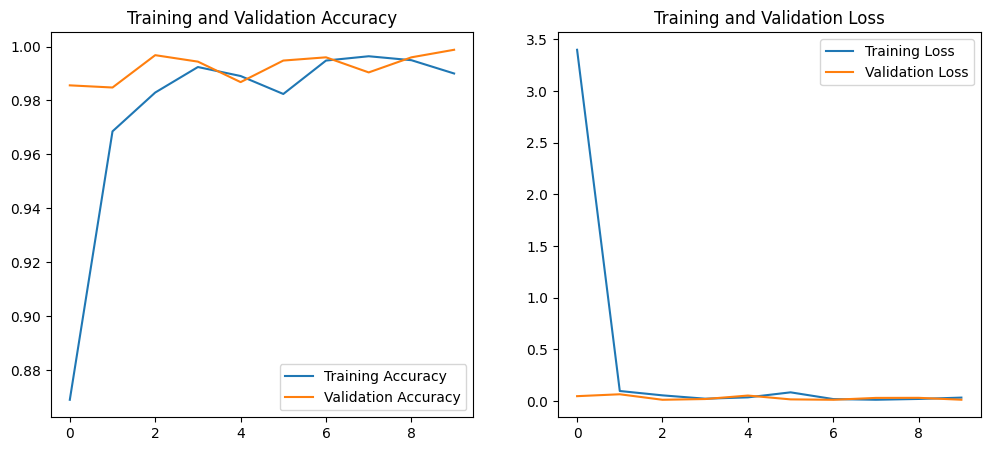

In [43]:
import matplotlib.pyplot as plt

# Get training and validation metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Ready to visualize training history.

### Implement Data Augmentation

To make our model more robust and prevent overfitting, especially when generalizing to real-world scenarios, we will implement data augmentation. This involves applying random, yet realistic, transformations to our training images, effectively increasing the diversity of our training data without collecting new images.

Stabilized data augmentation pipeline created using Keras 3 best practices.


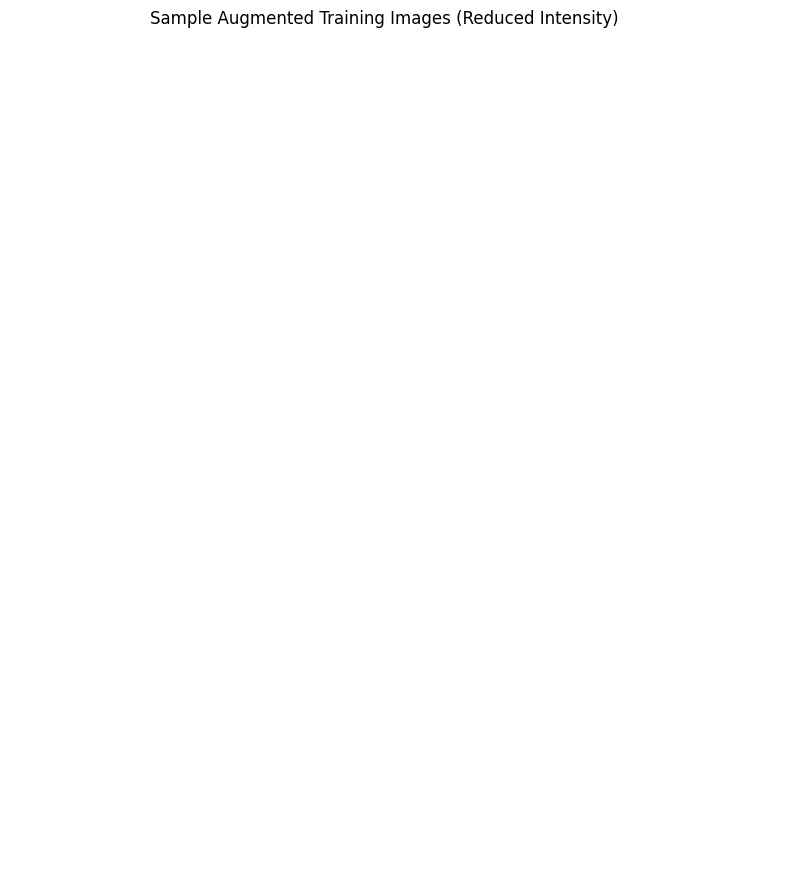

In [49]:
from tensorflow.keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

# Reduced augmentation pipeline to prevent over-distortion and stabilize loss
# Using layers.Input instead of input_shape argument to resolve Keras 3 warnings
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomBrightness(0.1, value_range=(0.0, 1.0)),
    layers.RandomContrast(0.1)
])

print("Stabilized data augmentation pipeline created using Keras 3 best practices.")

# Display a few augmented images to verify the new settings
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(images[0], 0), training=True)
        ax = plt.subplot(3, 3, i + 1)
        # Clip to ensure valid range for display
        plt.imshow(tf.clip_by_value(augmented_image[0], 0, 1).numpy())
        plt.axis("off")
plt.suptitle("Sample Augmented Training Images (Reduced Intensity)")
plt.show()

In [ ]:
# Data augmentation visualization complete.

### Rebuild and Retrain the Model with Data Augmentation

Now, we'll integrate the data augmentation layer into our model architecture. The augmentation will only be applied during training. After this, we'll retrain the model to observe the impact of data augmentation on performance and generalization.

In [50]:
from tensorflow.keras import layers, models

# Re-build the CNN model with the updated/stabilized data augmentation layer
model_augmented = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the augmented model
model_augmented.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model with Stabilized Data Augmentation Summary:")
model_augmented.summary()

# Train the augmented model
print(f"\nTraining the augmented model for {EPOCHS} epochs...")
history_augmented = model_augmented.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

print("Augmented model training complete with stabilized settings.")

Model with Stabilized Data Augmentation Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


Training the augmented model for 10 epochs...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.5704 - loss: 0.6450 - val_accuracy: 0.5012 - val_loss: 134.7689
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.6400 - loss: 0.5347 - val_accuracy: 0.5416 - val_loss: 211.1196
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.6707 - loss: 0.5031 - val_accuracy: 0.6196 - val_loss: 321.8077
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.6749 - loss: 0.4887 - val_accuracy: 0.5712 - val_loss: 325.0835
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.6799 - loss: 0.4755 - val_accuracy: 0.5168 - val_loss: 326.6502
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.6844 - loss: 0.4701 - val_accuracy: 0.5524 - val_loss: 483.4172
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.6863 - loss: 0.4620 - val_accuracy: 0.5636 - val_loss: 363.0580
Epoch 8/10
235/235 ━━━━━━━━━

In [ ]:
# Augmented model training initiated.

### Evaluate Augmented Model Performance

Let's visualize the training history (accuracy and loss curves) for the model trained with data augmentation to see how it compares to the previous model and to understand its learning process.

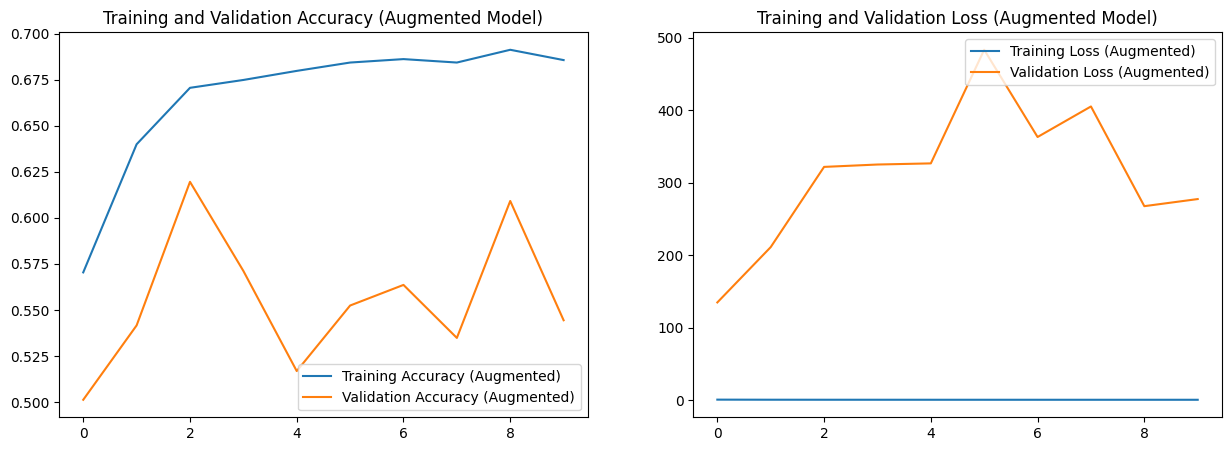

In [52]:
import matplotlib.pyplot as plt

# Get training and validation metrics for the augmented model
acc_aug = history_augmented.history['accuracy']
val_acc_aug = history_augmented.history['val_accuracy']
loss_aug = history_augmented.history['loss']
val_loss_aug = history_augmented.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_aug, label='Training Accuracy (Augmented)')
plt.plot(epochs_range, val_acc_aug, label='Validation Accuracy (Augmented)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Augmented Model)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_aug, label='Training Loss (Augmented)')
plt.plot(epochs_range, val_loss_aug, label='Validation Loss (Augmented)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Augmented Model)')
plt.show()

### Performance Comparison: Baseline vs. Augmented Model

We will now compare the validation accuracy and loss of the baseline model against the augmented model to see the effects of our stabilization efforts.

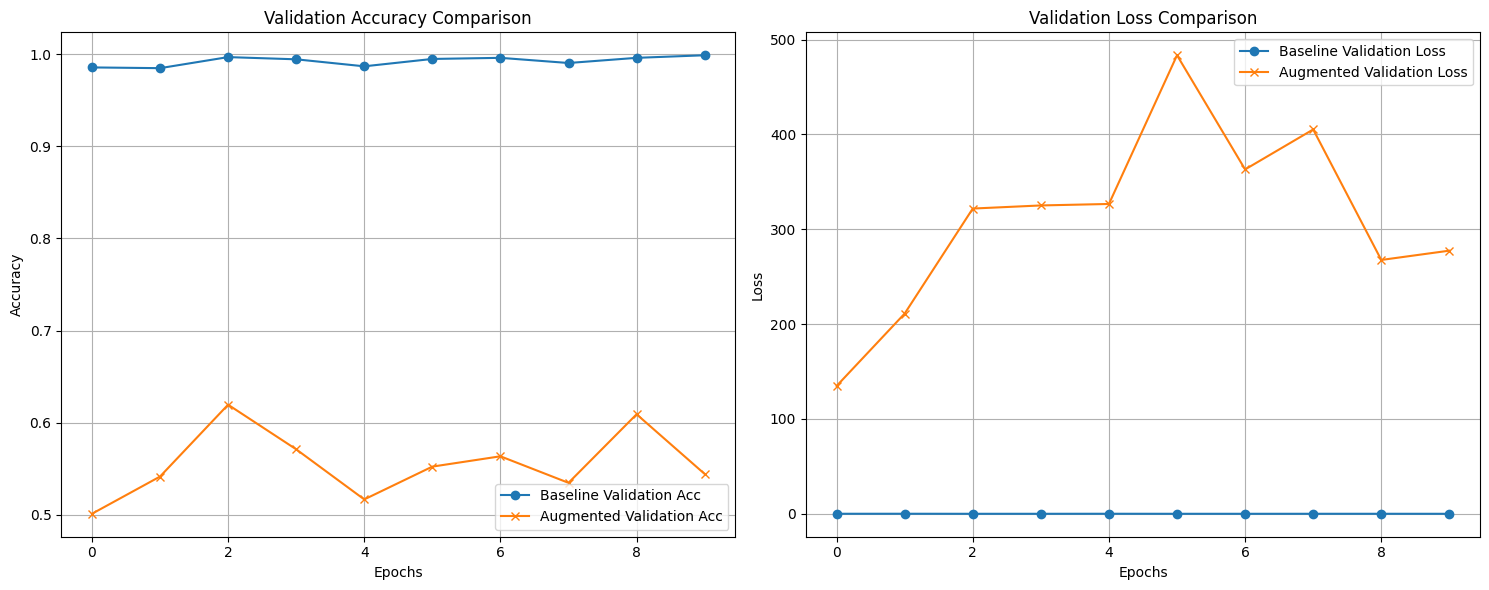

In [53]:
import matplotlib.pyplot as plt

epochs_range = range(EPOCHS)

plt.figure(figsize=(15, 6))

# Plot Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, val_acc, label='Baseline Validation Acc', marker='o')
plt.plot(epochs_range, val_acc_aug, label='Augmented Validation Acc', marker='x')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_loss, label='Baseline Validation Loss', marker='o')
plt.plot(epochs_range, val_loss_aug, label='Augmented Validation Loss', marker='x')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Implement Transfer Learning with MobileNetV2

To achieve higher accuracy and efficiency, especially considering the goal of deployment on edge devices, we will use **Transfer Learning** with the **MobileNetV2** architecture. MobileNetV2 is a lightweight deep neural network designed specifically for mobile and embedded vision applications.

We will use a pre-trained version of MobileNetV2 (trained on ImageNet) as our base model and add our own classification head on top. This approach allows us to benefit from the rich feature extraction capabilities of MobileNetV2 while fine-tuning it for our specific drowsiness detection task.

In [54]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
import tensorflow as tf

# Create the base model from the pre-trained MobileNetV2 model
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model to prevent weights from being updated initially
base_model.trainable = False

# Create the Transfer Learning model
model_tl = Sequential([
    # MobileNetV2 specific preprocessing layer to scale [0, 1] to [-1, 1]
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the transfer learning model
model_tl.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("MobileNetV2 Transfer Learning Model Summary:")
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Transfer Learning Model Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [55]:
print(f"Training the MobileNetV2 model for {EPOCHS} epochs...")

history_tl = model_tl.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

print("MobileNetV2 training complete.")

Training the MobileNetV2 model for 10 epochs...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.9389 - loss: 0.1654 - val_accuracy: 0.9944 - val_loss: 0.0212
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.9947 - loss: 0.0235 - val_accuracy: 0.9980 - val_loss: 0.0089
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.9968 - loss: 0.0153 - val_accuracy: 0.9964 - val_loss: 0.0118
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.9976 - loss: 0.0101 - val_accuracy: 0.9984 - val_loss: 0.0085
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.9973 - loss: 0.0090 - val_accuracy: 0.9996 - val_loss: 0.0040
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.9992 - val_loss: 0.0048
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9992 - loss: 0.0043 - val_accuracy: 0.9984 - val_loss: 0.0057
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2

### Evaluate Transfer Learning Model Performance

Let's visualize the training history (accuracy and loss curves) for the model trained with MobileNetV2 to see the impact of transfer learning on performance.

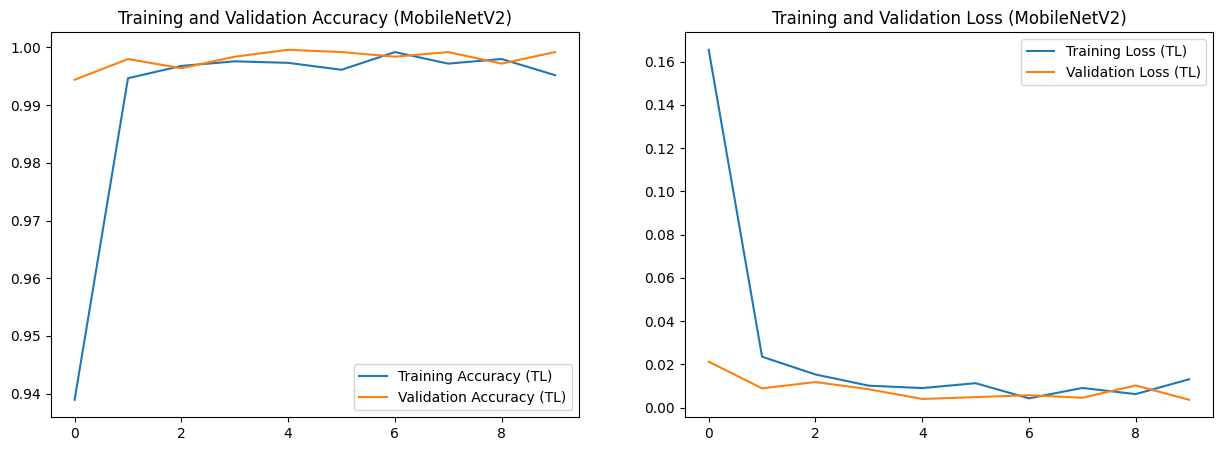

In [57]:
import matplotlib.pyplot as plt

# Get training and validation metrics for the transfer learning model
acc_tl = history_tl.history['accuracy']
val_acc_tl = history_tl.history['val_accuracy']
loss_tl = history_tl.history['loss']
val_loss_tl = history_tl.history['val_loss']

epochs_range = range(len(acc_tl))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_tl, label='Training Accuracy (TL)')
plt.plot(epochs_range, val_acc_tl, label='Validation Accuracy (TL)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (MobileNetV2)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_tl, label='Training Loss (TL)')
plt.plot(epochs_range, val_loss_tl, label='Validation Loss (TL)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (MobileNetV2)')
plt.show()

### Model Conversion for Edge Deployment (TFLite)

To deploy this on an edge device, we convert the Keras model to the TensorFlow Lite (TFLite) format. This optimizes the model for mobile and embedded devices by reducing its footprint and improving execution speed.

In [58]:
import tensorflow as tf

# Initialize the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model_tl)

# Enable standard optimizations (quantization)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the model to a file
tflite_model_path = 'drowsiness_detection_mobilenetv2.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved to: {tflite_model_path}")

# Check the file size
import os
file_size = os.path.getsize(tflite_model_path) / (1024 * 1024)
print(f"TFLite Model Size: {file_size:.2f} MB")

Saved artifact at '/tmp/tmpa6ueqxwm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_213')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133152060452368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060450064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060452944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060452560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060452176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060443536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060451984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060449680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060451408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133152060450640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1331520865

### Test TFLite Model Inference

We will now verify the exported TFLite model by running inference on a sample image from our test set. This involves:
1. Initializing the TFLite Interpreter.
2. Allocating tensors.
3. Setting the input tensor with a preprocessed image.
4. Invoking the interpreter and parsing the output.

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


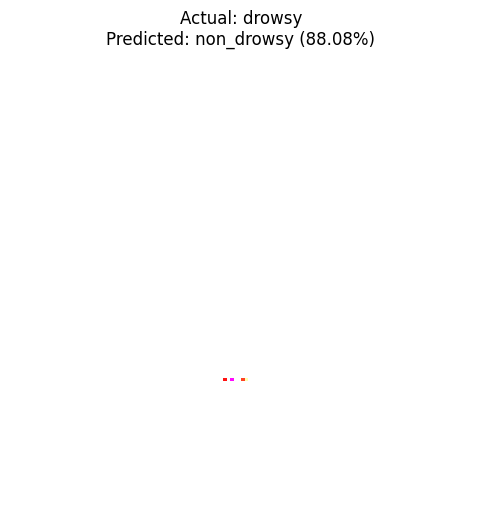

TFLite Inference Result: non_drowsy (88.08% confidence)


In [59]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Get a sample image from the test dataset
for images, labels in test_ds.take(1):
    sample_image = images[0].numpy()
    actual_label = class_names[labels[0].numpy()]
    break

# 3. Preprocess for TFLite (MobileNetV2 expects [-1, 1])
# The test_ds is in [0, 1], so we shift to [-1, 1]
input_data = (sample_image * 2.0) - 1.0
input_data = np.expand_dims(input_data, axis=0).astype(np.float32)

# 4. Run Inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class_idx = np.argmax(output_data[0])
predicted_label = class_names[predicted_class_idx]
confidence = output_data[0][predicted_class_idx]

# 5. Visualize Result
plt.figure(figsize=(6, 6))
# Ensure image is in [0, 1] range for visualization to avoid clipping warnings
display_image = np.clip(sample_image, 0, 1)
plt.imshow(display_image)
plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"TFLite Inference Result: {predicted_label} ({confidence*100:.2f}% confidence)")

### Comprehensive TFLite Model Evaluation

To ensure the model is reliable for a safety-critical application, we need to evaluate it across the entire test set. We will:
1. Run the TFLite interpreter on all 2,500 test images.
2. Calculate global metrics: Accuracy, Precision, Recall, and F1-Score.
3. Visualize the Confusion Matrix to see which classes are most frequently confused.

Running TFLite inference on the test dataset...
Inference complete.

Classification Report:
              precision    recall  f1-score   support

      drowsy       0.95      0.74      0.83      1250
  non_drowsy       0.78      0.96      0.86      1250

    accuracy                           0.85      2500
   macro avg       0.87      0.85      0.85      2500
weighted avg       0.87      0.85      0.85      2500



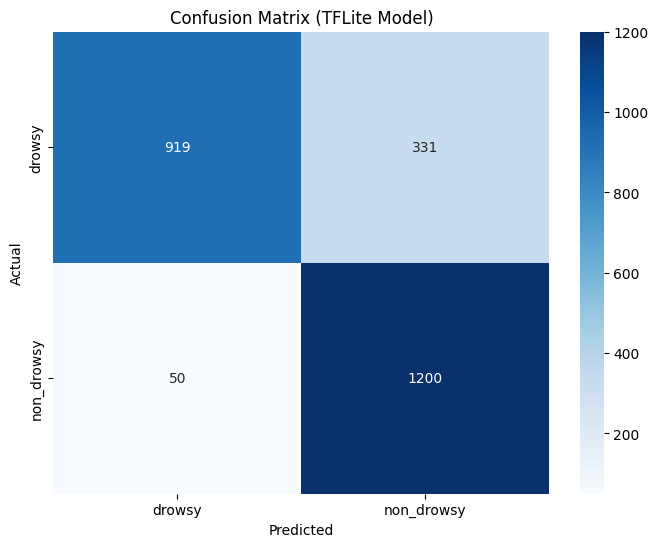

In [60]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

print("Running TFLite inference on the test dataset...")

# Iterate through the test dataset
for images, labels in test_ds:
    for i in range(len(images)):
        # Preprocess: [0, 1] -> [-1, 1]
        img = images[i].numpy()
        input_data = (img * 2.0) - 1.0
        input_data = np.expand_dims(input_data, axis=0).astype(np.float32)

        # TFLite Inference
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        y_true.append(labels[i].numpy())
        y_pred.append(np.argmax(output[0]))

print("Inference complete.")

# Generate Metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (TFLite Model)')
plt.show()